# Try running a RAIL estimator on the degraded pop-cosmos integrated catalog

In [1]:
### Imports
import numpy as np
import h5py

import rail.interactive as ri
import tables_io
from rail.utils.path_utils import find_rail_file

Install FSPS with the following commands:
pip uninstall fsps
git clone --recursive https://github.com/dfm/python-fsps.git
cd python-fsps
python -m pip install .
export SPS_HOME=$(pwd)/src/fsps/libfsps

LEPHAREDIR is being set to the default cache directory:
/Users/leo/Library/Caches/lephare/data
More than 1Gb may be written there.
LEPHAREWORK is being set to the default cache directory:
/Users/leo/Library/Caches/lephare/work
Default work cache is already linked. 
This is linked to the run directory:
/Users/leo/Library/Caches/lephare/runs/20260227T152408


# Model parameters

In [2]:
data_file_path = '/Users/leo/Projects/LBG_cosmology/simulated_catalogs/integrated_catalog_23apr26_noised_19Jun26.pq'

training_fraction = 0.8
reference_band = 'LSST_u'

flexZBoost_parameters = dict(
    zmin              = 0.0,
    zmax              = 3.0,
    nzbins            = 301,
    trainfrac         = 0.75,
    bumpmin           = 0.02,
    bumpmax           = 0.35,
    nbump             = 20,
    sharpmin          = 0.7,
    sharpmax          = 2.1,
    nsharp            = 15,
    max_basis         = 35,
    basis_system      = "cosine",
    regression_params = {"max_depth": 8, "objective": "reg:squarederror"},
)

seed = 42

In [3]:
m5_limiting_depths = {'LSST_u'    : 27.74,
                      'LSST_g'    : 28.69,
                      'LSST_r'    : 28.88,
                      'LSST_i'    : 28.96,
                      'LSST_z'    : 28.26,
                      'LSST_y'    : 26.63,
                      'Roman_F062': 27.7,
                      'Roman_F087': 27.7,
                      'Roman_F106': 27.6,
                      'Roman_F129': 27.5,
                      'Roman_F158': 27.0,
                      'Roman_F184': 25.9,
                      'Roman_F213': 28.3,
                      'HSC_MB_00' : 26.41,
                      'HSC_MB_01' : 26.51,
                      'HSC_MB_02' : 26.45,
                      'HSC_MB_03' : 26.69,
                      'HSC_MB_04' : 26.93,
                      'HSC_MB_05' : 26.62,
                      'HSC_MB_06' : 26.26,
                      'HSC_MB_07' : 26.02,
                      'HSC_MB_08' : 26.07,
                      'HSC_MB_09' : 26.00,
                      'HSC_MB_10' : 26.06,
                      'HSC_MB_11' : 25.52,
                      'HSC_MB_12' : 25.58,
                      'HSC_MB_13' : 25.43,
                      'HSC_MB_14' : 25.15,
                      'HSC_MB_15' : 24.79}

# Load data

In [4]:
data_cut = int(1e5)

In [5]:
data_file = find_rail_file(data_file_path)
data = tables_io.read(data_file)

data = data[:data_cut]

training_indices = np.zeros(len(data), dtype = bool)
training_indices[np.random.choice(len(data), size = int(training_fraction * len(data)),
                 replace = False)] = True

bands = [key for key in data.keys() if (not key.endswith('_err')) & (key != 'Roman_F146')]
error_bands = [key for key in data.keys() if key.endswith('_err')]

validation_data = data[~training_indices]
training_data   = data[training_indices]

column_list None


In [6]:
redshift_filepath = '/Users/leo/Projects/LBG_cosmology/surveys/pop-cosmos/mock_catalog/mock_catalog_Ch1_26.h5'
redshifts = h5py.File(redshift_filepath)['sfh_parameters'][:, -1]

In [7]:
training_data['redshift'] = redshifts[training_data.index]

# Inform the estimator

In [8]:
#monkey-patch trapz
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

In [ ]:
flexZBoost_informer = ri.estimation.algos.flexzboost.flex_z_boost_informer(
    training_data = training_data, hdf5_groupname = "",
    bands = bands, err_bands = error_bands,
    ref_band = reference_band, redshift_col = 'redshift',
    mag_limits = m5_limiting_depths,
    **flexZBoost_parameters
)

Inserting handle into data store.  input: None, FlexZBoostInformer
stacking some data...
read in training data
fit the model...


/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:26:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:26:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:26:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [15:26:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "silent" } are not used.

  bst.up

# Estimate redshifts

In [36]:
flexZBoost_estimator = ri.estimation.algos.flexzboost.flex_z_boost_estimator(
    input_data = validation_data, hdf5_groupname = "",
    model = flexZBoost_informer['model'],
    bands = bands, err_bands = error_bands, ref_band = reference_band,
    mag_limits = m5_limiting_depths
)

Inserting handle into data store.  input: None, FlexZBoostEstimator
Inserting handle into data store.  model: <flexcode.core.FlexCodeModel object at 0x1411b60d0>, FlexZBoostEstimator
Process 0 running estimator on chunk 0 - 20,000
Process 0 estimating PZ PDF for rows 0 - 20,000
Inserting handle into data store.  output: inprogress_output.hdf5, FlexZBoostEstimator


# Plot redshifts

In [39]:
import matplotlib.pyplot as plt
plt.style.use('/Users/leo/Projects/LBG_cosmology/code/umap_nz_cal.mplstyle')

Text(0, 0.5, 'Density')

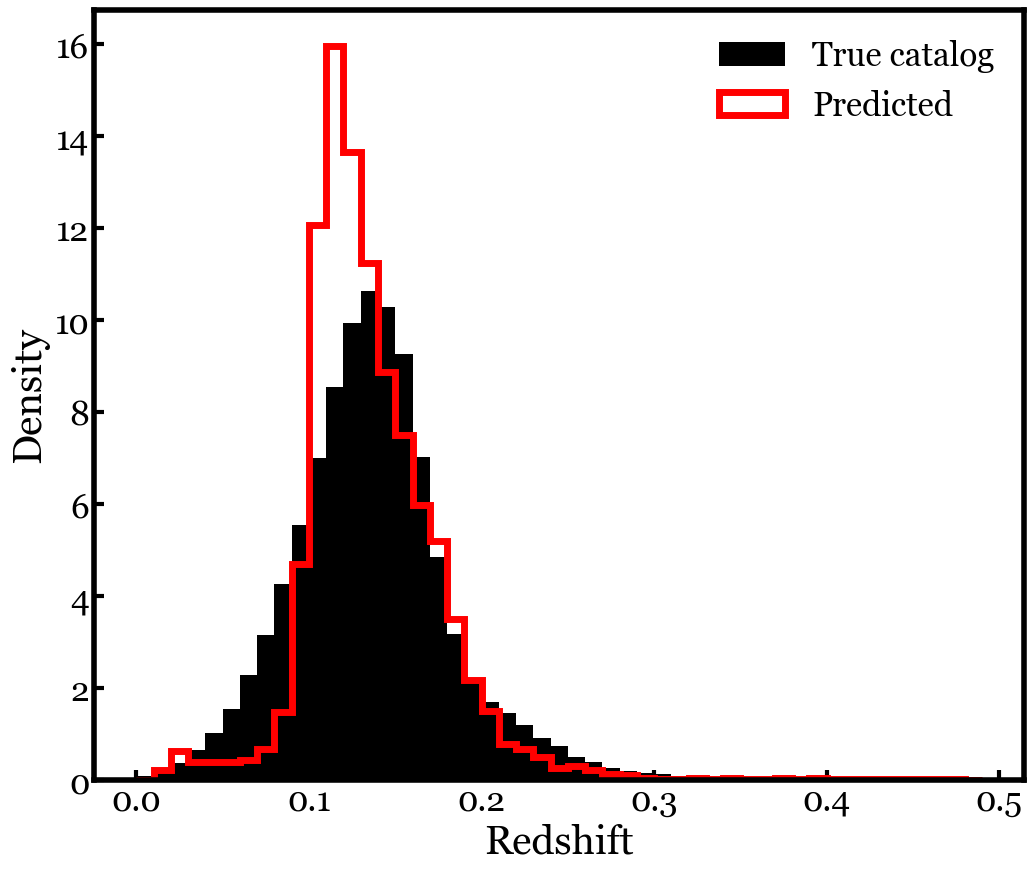

In [80]:
allMedians = flexZBoost_estimator["output"].median()

fig = plt.figure()
ax = fig.add_subplot()

bins = np.arange(0, .5, 0.01)

ax.hist(training_data['redshift'], bins = bins, density = True,
        color = 'black',
        label = 'True catalog')
ax.hist(allMedians, bins = bins, density = True,
        histtype = 'step', color = 'red', linewidth = 5,
        label = 'Predicted')

ax.legend(frameon = False)
ax.set_xlabel('Redshift')
ax.set_ylabel('Density')

In [40]:
x_axis = np.linspace(0, 3, 301)

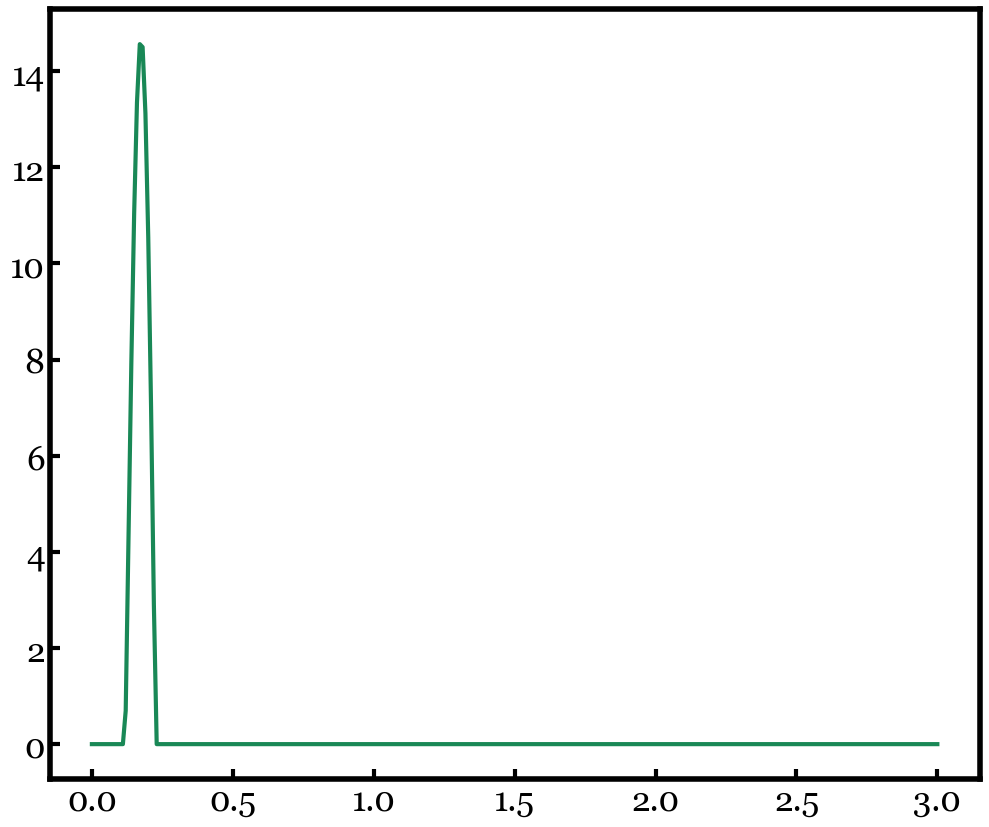

In [62]:
fig = plt.figure()
ax = fig.add_subplot()

sourceID = 39
ax.plot(x_axis, flexZBoost_estimator["output"][sourceID].pdf(x_axis))